# HR Analytics & Employee Attrition Prediction

**Menggabungkan Data Analytics dan Predictive Machine Learning untuk Membantu HR Memahami dan Mengurangi Employee Attrition**

---
*Portfolio Project — Data Analyst & Data Scientist*


## 1. Domain Proyek

### Latar Belakang

Karyawan adalah aset utama perusahaan. Ketika karyawan yang berpengalaman resign, perusahaan tidak hanya kehilangan orangnya, tapi juga waktu dan biaya untuk merekrut serta melatih pengganti, plus produktivitas tim yang sempat terganggu selama masa transisi.

Fenomena karyawan yang keluar dari perusahaan ini disebut **employee attrition**. Attrition itu wajar terjadi di perusahaan mana pun, tapi kalau angkanya terlalu tinggi atau terjadi berulang pada kelompok karyawan tertentu, ini jadi sinyal bahwa ada sesuatu yang perlu dibenahi — entah itu soal beban kerja, kompensasi, jenjang karier, atau hal lain.

Masalahnya, banyak perusahaan baru sadar ada masalah attrition **setelah** karyawan resign. Padahal kalau HR punya cara untuk melihat pola attrition dari data yang sudah dimiliki, mereka bisa lebih proaktif — baik untuk memperbaiki kebijakan secara umum, maupun untuk mengidentifikasi karyawan yang kemungkinan besar berisiko keluar.

Di sinilah data analytics dan machine learning bisa membantu. Dengan data historis karyawan (departemen, lama bekerja, kepuasan kerja, lembur, dan lain-lain), kita bisa:
- Memetakan kondisi workforce secara keseluruhan
- Melihat kelompok mana yang attrition-nya lebih tinggi
- Membangun model yang bisa memberi skor risiko attrition per karyawan

### Business Context

**Masalah bisnis:** perusahaan ingin memahami pola attrition karyawannya dan punya alat bantu untuk mengidentifikasi karyawan yang berisiko keluar, supaya tim HR bisa mengambil langkah retensi sebelum terlambat.

**Stakeholder utama:**
- **Tim HR** — pengguna utama insight dan model ini, untuk merancang strategi retensi
- **Manajer departemen** — perlu tahu kondisi tim mereka masing-masing
- **Manajemen/leadership** — perlu gambaran besar soal kesehatan workforce untuk pengambilan keputusan strategis

**Bagaimana hasil project ini dipakai:** analisis EDA memberi gambaran kondisi workforce dan pola attrition secara umum untuk dasar kebijakan, sementara model machine learning bisa dipakai sebagai *early warning system* — memberi skor risiko ke tiap karyawan supaya HR bisa fokus intervensi ke kelompok yang paling berisiko, bukan menyamaratakan semua orang.


## 2. Business Understanding

### A. Problem Statements

1. Bagaimana karakteristik workforce perusahaan berdasarkan data yang tersedia (departemen, job role, usia, income, tenure, dll)?
2. Bagaimana pola employee attrition di berbagai kelompok karyawan?
3. Faktor apa saja yang paling berkaitan dengan attrition karyawan?
4. Apakah machine learning bisa digunakan untuk memprediksi karyawan mana yang berisiko attrition?
5. Bagaimana hasil analisis dan model ini bisa membantu HR menentukan strategi retensi yang lebih terarah?

### B. Goals

- Memahami karakteristik dan kondisi workforce secara umum
- Mengukur attrition rate secara keseluruhan dan per kelompok karyawan
- Mengidentifikasi faktor-faktor yang paling berkaitan dengan attrition
- Membangun model klasifikasi yang bisa memprediksi kemungkinan attrition seorang karyawan dengan performa yang cukup baik
- Menerjemahkan hasil model (feature importance) menjadi insight yang bisa dipahami HR
- Merumuskan rekomendasi bisnis yang konkret dan actionable untuk tim HR

### C. Solution Statement

Pendekatan yang dipakai untuk menjawab problem statement di atas:

1. **Data Understanding** — memahami struktur, tipe data, dan kualitas dataset
2. **Data Cleaning** — menangani kolom yang tidak relevan dan memastikan data konsisten
3. **Exploratory Data Analysis** — eksplorasi workforce dan pola attrition
4. **Employee Attrition Analysis** — fokus khusus melihat attrition rate per kelompok
5. **Feature Engineering** — membuat fitur turunan yang punya alasan bisnis
6. **Data Preprocessing** — encoding, scaling, dan pipeline supaya tidak ada data leakage
7. **Machine Learning** — melatih beberapa model klasifikasi untuk memprediksi attrition
8. **Model Evaluation** — membandingkan model dengan beberapa metrik, bukan cuma accuracy
9. **Model Interpretation** — melihat fitur apa yang paling berpengaruh terhadap prediksi
10. **Business Insights** — menerjemahkan semua temuan jadi insight yang jelas
11. **Business Recommendations** — rekomendasi HR yang actionable berdasarkan temuan


## Setup

Import library yang dibutuhkan dan atur konfigurasi dasar untuk notebook ini.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              RocCurveDisplay)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
COLOR_STAY = '#4C72B0'
COLOR_LEAVE = '#DD8452'


## 3. Data Understanding

### A. Sumber Dataset

Dataset yang dipakai adalah data karyawan perusahaan, diambil dari:

`https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv`

In [ ]:
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv'
df = pd.read_csv(url)
df.head()


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,4,Male,88,3,1,Human Resources,2,Married,2991,5224,0,Y,Yes,11,3,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,Female,61,1,2,Healthcare Representative,2,Married,4777,14382,5,Y,No,15,3,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Y,Yes,12,3,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,Female,77,3,4,Sales Executive,2,Married,13525,14864,5,Y,No,14,3,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,3,Female,98,3,1,Research Scientist,3,Married,2001,12549,2,Y,No,14,3,2,80,3,20,2,3,5,3,0,2


### B. Gambaran Umum Dataset

In [ ]:
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")
print()
df.info()


Jumlah baris  : 1470
Jumlah kolom  : 35

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 no

Dataset ini berisi **1.470 baris** dan **35 kolom**, dengan setiap baris merepresentasikan satu karyawan. Sebagian besar kolom bertipe numerik, dan beberapa bertipe kategorikal (object), seperti `Department`, `JobRole`, `OverTime`, dan lain-lain.

### C. Data Dictionary

In [ ]:
data_dict = pd.DataFrame([
    ['EmployeeId', 'Numerik', 'ID unik tiap karyawan', 'Identifier'],
    ['Age', 'Numerik', 'Usia karyawan', 'Feature'],
    ['Attrition', 'Numerik (0/1)', 'Status keluar dari perusahaan (1 = keluar, 0 = bertahan)', 'Target'],
    ['BusinessTravel', 'Kategorikal', 'Frekuensi perjalanan dinas karyawan', 'Feature'],
    ['DailyRate', 'Numerik', 'Tarif harian karyawan', 'Feature'],
    ['Department', 'Kategorikal', 'Departemen tempat karyawan bekerja', 'Feature'],
    ['DistanceFromHome', 'Numerik', 'Jarak rumah ke kantor (km)', 'Feature'],
    ['Education', 'Numerik (1-5)', 'Level pendidikan (1=rendah, 5=tinggi)', 'Feature'],
    ['EducationField', 'Kategorikal', 'Bidang pendidikan karyawan', 'Feature'],
    ['EmployeeCount', 'Numerik', 'Selalu bernilai 1, tidak informatif', 'Drop'],
    ['EnvironmentSatisfaction', 'Numerik (1-4)', 'Tingkat kepuasan terhadap lingkungan kerja', 'Feature'],
    ['Gender', 'Kategorikal', 'Jenis kelamin karyawan', 'Feature'],
    ['HourlyRate', 'Numerik', 'Tarif per jam karyawan', 'Feature'],
    ['JobInvolvement', 'Numerik (1-4)', 'Tingkat keterlibatan dalam pekerjaan', 'Feature'],
    ['JobLevel', 'Numerik (1-5)', 'Level jabatan karyawan', 'Feature'],
    ['JobRole', 'Kategorikal', 'Peran/posisi pekerjaan karyawan', 'Feature'],
    ['JobSatisfaction', 'Numerik (1-4)', 'Tingkat kepuasan terhadap pekerjaan', 'Feature'],
    ['MaritalStatus', 'Kategorikal', 'Status pernikahan karyawan', 'Feature'],
    ['MonthlyIncome', 'Numerik', 'Pendapatan bulanan karyawan', 'Feature'],
    ['MonthlyRate', 'Numerik', 'Tarif bulanan karyawan', 'Feature'],
    ['NumCompaniesWorked', 'Numerik', 'Jumlah perusahaan tempat karyawan pernah bekerja sebelumnya', 'Feature'],
    ['Over18', 'Kategorikal', 'Selalu bernilai Y, tidak informatif', 'Drop'],
    ['OverTime', 'Kategorikal', 'Apakah karyawan sering lembur (Yes/No)', 'Feature'],
    ['PercentSalaryHike', 'Numerik', 'Persentase kenaikan gaji terakhir', 'Feature'],
    ['PerformanceRating', 'Numerik (1-4)', 'Rating performa karyawan', 'Feature'],
    ['RelationshipSatisfaction', 'Numerik (1-4)', 'Tingkat kepuasan relasi kerja', 'Feature'],
    ['StandardHours', 'Numerik', 'Selalu bernilai 80, tidak informatif', 'Drop'],
    ['StockOptionLevel', 'Numerik (0-3)', 'Level kepemilikan opsi saham karyawan', 'Feature'],
    ['TotalWorkingYears', 'Numerik', 'Total tahun pengalaman kerja karyawan', 'Feature'],
    ['TrainingTimesLastYear', 'Numerik', 'Jumlah training yang diikuti tahun lalu', 'Feature'],
    ['WorkLifeBalance', 'Numerik (1-4)', 'Tingkat keseimbangan kerja-hidup', 'Feature'],
    ['YearsAtCompany', 'Numerik', 'Lama bekerja di perusahaan saat ini (tahun)', 'Feature'],
    ['YearsInCurrentRole', 'Numerik', 'Lama menjabat di posisi saat ini (tahun)', 'Feature'],
    ['YearsSinceLastPromotion', 'Numerik', 'Tahun sejak promosi terakhir', 'Feature'],
    ['YearsWithCurrManager', 'Numerik', 'Lama bekerja dengan manager saat ini (tahun)', 'Feature'],
], columns=['Column', 'Data Type', 'Description', 'Role'])

data_dict


,Column,Data Type,Description,Role
0,EmployeeId,Numerik,ID unik tiap karyawan,Identifier
1,Age,Numerik,Usia karyawan,Feature
2,Attrition,Numerik (0/1),"Status keluar dari perusahaan (1 = keluar, 0 =...",Target
3,BusinessTravel,Kategorikal,Frekuensi perjalanan dinas karyawan,Feature
4,DailyRate,Numerik,Tarif harian karyawan,Feature
5,Department,Kategorikal,Departemen tempat karyawan bekerja,Feature
6,DistanceFromHome,Numerik,Jarak rumah ke kantor (km),Feature
7,Education,Numerik (1-5),"Level pendidikan (1=rendah, 5=tinggi)",Feature
8,EducationField,Kategorikal,Bidang pendidikan karyawan,Feature
9,EmployeeCount,Numerik,"Selalu bernilai 1, tidak informatif",Drop


Keterangan skala untuk kolom rating (1-4 atau 1-5) mengikuti konvensi umum di dataset HR: semakin besar angkanya, semakin tinggi/positif kondisinya (misalnya `JobSatisfaction` 4 berarti sangat puas, 1 berarti sangat tidak puas).

### D. Data Quality

In [ ]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print("=== Duplicate Rows ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print(f"Jumlah EmployeeId duplikat: {df['EmployeeId'].duplicated().sum()}")


=== Missing Values ===
Attrition    412
dtype: int64

=== Duplicate Rows ===
Jumlah baris duplikat: 0
Jumlah EmployeeId duplikat: 0


In [ ]:
# Cek kolom yang nilainya konstan (tidak ada variasi -> tidak informatif)
for col in ['EmployeeCount', 'StandardHours', 'Over18']:
    print(f"{col}: {df[col].unique()}")


EmployeeCount: [1]
StandardHours: [80]
Over18: <StringArray>
['Y']
Length: 1, dtype: str


Hasil pengecekan data quality:

- **Tidak ada baris duplikat**, dan `EmployeeId` juga unik untuk setiap baris — dataset ini bersih dari duplikasi.
- Satu-satunya kolom yang punya missing value adalah **`Attrition`** (kolom target) — akan dibahas lebih detail di bagian Target Variable.
- Tiga kolom (`EmployeeCount`, `StandardHours`, `Over18`) ternyata **cuma punya satu nilai unik** untuk seluruh baris, jadi tidak memberi informasi apa pun buat analisis maupun model. Kolom-kolom ini akan di-drop di tahap Data Preparation.

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,735.500000,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
Attrition,1058.0,0.169187,0.375094,0.0,0.00,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0


Dari statistik deskriptif ini kolom-kolom numerik terlihat dalam rentang yang masuk akal (misalnya `Age` antara 18-60 tahun, rating kepuasan antara 1-4), jadi tidak ada indikasi kuat nilai yang aneh atau error input.

### E. Target Variable

In [ ]:
print(df['Attrition'].value_counts(dropna=False))
print()
print("Persentase (termasuk missing):")
print((df['Attrition'].value_counts(dropna=False, normalize=True) * 100).round(1))


Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64

Persentase (termasuk missing):
Attrition
0.0    59.8
NaN    28.0
1.0    12.2
Name: proportion, dtype: float64


Kolom target project ini adalah **`Attrition`**, dengan arti:
- **0** = karyawan masih bertahan di perusahaan
- **1** = karyawan sudah keluar (attrition)

Yang menarik, kolom ini punya **412 baris kosong (NaN)** — bukan error, tapi memang ada sekelompok karyawan yang status attrition-nya belum tercatat/diketahui. Dari 1.058 baris yang berlabel jelas:
- **879 karyawan (83.1%)** masih bertahan
- **179 karyawan (16.9%)** sudah keluar (attrition)

Attrition rate sekitar **16.9%** ini yang jadi baseline analisis kita. Untuk proses training dan evaluasi model, kita hanya akan pakai 1.058 baris yang punya label jelas — sedangkan 412 baris yang belum berlabel nanti dipakai sebagai contoh penerapan model di dunia nyata: memberi skor risiko attrition ke karyawan yang statusnya belum diketahui (bagian 9).

Perlu dicatat juga: proporsi kelas 83/17 ini cukup **imbalanced**. Ini akan mempengaruhi pemilihan metrik evaluasi model nanti — accuracy saja tidak cukup untuk menilai model yang baik.

## 4. Data Preparation

### A. Data Cleaning

Berdasarkan pengecekan data quality sebelumnya, dataset ini sebenarnya sudah cukup rapi. Langkah cleaning yang dilakukan:

1. **Drop kolom tidak informatif**: `EmployeeCount`, `StandardHours`, `Over18` — karena nilainya konstan di semua baris.
2. **Pisahkan baris dengan target diketahui vs tidak diketahui**: baris dengan `Attrition` yang kosong tidak bisa dipakai untuk training/evaluasi (karena kita tidak tahu jawaban benarnya), jadi disimpan terpisah untuk dipakai di bagian prediksi.
3. Tidak ada duplicate row atau inconsistent category yang perlu ditangani, karena sudah dicek bersih di tahap Data Understanding.

In [ ]:
df_clean = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])

# Pisahkan data yang punya label (untuk training & evaluasi) dan yang belum berlabel (untuk prediksi nanti)
labeled = df_clean.dropna(subset=['Attrition']).copy()
labeled['Attrition'] = labeled['Attrition'].astype(int)

unlabeled = df_clean[df_clean['Attrition'].isna()].copy()

print(f"Data berlabel   : {labeled.shape[0]} baris -> dipakai untuk training & evaluasi model")
print(f"Data belum berlabel: {unlabeled.shape[0]} baris -> dipakai untuk simulasi prediksi risiko attrition")


Data berlabel   : 1058 baris -> dipakai untuk training & evaluasi model
Data belum berlabel: 412 baris -> dipakai untuk simulasi prediksi risiko attrition


### B. Feature Selection

`EmployeeId` adalah identifier unik tiap karyawan dan tidak punya hubungan sebab-akibat dengan attrition — kolom ini dipisahkan dari fitur model supaya tidak "dihafal" oleh model (data leakage lewat ID).

In [ ]:
identifier_col = 'EmployeeId'
target_col = 'Attrition'

feature_cols = [c for c in labeled.columns if c not in [identifier_col, target_col]]
print(f"Jumlah fitur yang dipakai: {len(feature_cols)}")
print(feature_cols)


Jumlah fitur yang dipakai: 30
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### C. Feature Engineering

Beberapa fitur turunan ditambahkan karena punya alasan bisnis yang jelas dan sering dipakai dalam praktik HR analytics:

- **`TenureGroup`** — mengelompokkan `YearsAtCompany` jadi kategori (Baru / 1-3 Tahun / 4-6 Tahun / 7-10 Tahun / Lebih dari 10 Tahun). Alasannya, HR biasanya lebih mudah membaca pola berdasarkan kelompok masa kerja daripada angka tahun mentah, dan dari eksplorasi awal karyawan baru cenderung berperilaku beda dari karyawan lama.
- **`IncomeGroup`** — mengelompokkan `MonthlyIncome` jadi kuartil (Q1 terendah - Q4 tertinggi). Berguna untuk melihat apakah level income tertentu (bukan cuma angka absolut) berkaitan dengan attrition.
- **`AvgSatisfaction`** — rata-rata dari `JobSatisfaction`, `EnvironmentSatisfaction`, dan `RelationshipSatisfaction`. Menggabungkan tiga indikator kepuasan jadi satu skor komposit, supaya lebih mudah melihat "kepuasan keseluruhan" karyawan tanpa harus melihat tiga kolom terpisah.

Ketiga fitur ini murni turunan dari kolom yang sudah ada di dataset (bukan informasi dari luar/masa depan), jadi tidak menyebabkan data leakage.

In [ ]:
def add_engineered_features(data):
    data = data.copy()

    # Tenure group
    bins = [-1, 0, 3, 6, 10, 100]
    labels = ['Baru (0 Tahun)', '1-3 Tahun', '4-6 Tahun', '7-10 Tahun', 'Lebih dari 10 Tahun']
    data['TenureGroup'] = pd.cut(data['YearsAtCompany'], bins=bins, labels=labels)

    # Income group (quartile, dihitung dari data training nanti supaya tidak leakage antar train-test)
    data['IncomeGroup'] = pd.qcut(data['MonthlyIncome'], q=4, labels=['Q1 (Terendah)', 'Q2', 'Q3', 'Q4 (Tertinggi)'])

    # Rata-rata skor kepuasan
    data['AvgSatisfaction'] = data[['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']].mean(axis=1)

    return data

labeled_fe = add_engineered_features(labeled)
labeled_fe[['YearsAtCompany', 'TenureGroup', 'MonthlyIncome', 'IncomeGroup', 'AvgSatisfaction']].head()


,YearsAtCompany,TenureGroup,MonthlyIncome,IncomeGroup,AvgSatisfaction
1,1,1-3 Tahun,4777,Q2,1.333333
2,10,7-10 Tahun,2461,Q1 (Terendah),2.333333
3,20,Lebih dari 10 Tahun,13525,Q4 (Tertinggi),3.000000
6,4,4-6 Tahun,7457,Q3,3.000000
7,5,4-6 Tahun,19859,Q4 (Tertinggi),3.000000


> **Catatan:** `TenureGroup`, `IncomeGroup`, dan `AvgSatisfaction` di atas dipakai khusus untuk kebutuhan **EDA** (supaya insight lebih mudah dibaca). Untuk **pipeline machine learning**, kita tetap pakai fitur numerik aslinya (`YearsAtCompany`, `MonthlyIncome`, skor satisfaction individual) supaya model tidak kehilangan detail informasi akibat proses binning, dan supaya `qcut` tidak dihitung dari keseluruhan data sebelum train-test split.

### D. Train-Test Split

Split dilakukan **sebelum** encoding/scaling, supaya proses preprocessing nanti murni "belajar" dari data training saja (tidak mengintip data test).

In [ ]:
X = labeled[feature_cols]
y = labeled[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Data training : {X_train.shape[0]} baris")
print(f"Data testing  : {X_test.shape[0]} baris")
print(f"Attrition rate training : {y_train.mean()*100:.1f}%")
print(f"Attrition rate testing  : {y_test.mean()*100:.1f}%")


Data training : 846 baris
Data testing  : 212 baris
Attrition rate training : 16.9%
Attrition rate testing  : 17.0%


Pakai `stratify=y` supaya proporsi kelas 0/1 di data training dan testing tetap seimbang (mirip proporsi aslinya), tidak kebetulan salah satu subset punya attrition rate yang jauh berbeda.

### E. Encoding & F. Scaling

- **Categorical features** (`Department`, `JobRole`, `OverTime`, dll) di-encode pakai **One-Hot Encoding**, karena kategori-kategori ini tidak punya urutan (nominal), jadi tidak tepat kalau diberi angka berurutan seperti Ordinal Encoding.
- **Numerical features** di-scale pakai **StandardScaler**. Ini penting terutama untuk Logistic Regression yang sensitif terhadap skala fitur (misalnya `MonthlyIncome` yang bisa ribuan, dibanding `JobSatisfaction` yang cuma 1-4).

### G. Pipeline

Semua langkah preprocessing digabung dalam satu `ColumnTransformer` + `Pipeline`, supaya:
- Proses fit hanya belajar dari data training
- Tidak ada risiko lupa apply preprocessing yang sama ke data test
- Mudah dipakai ulang untuk data baru (termasuk 412 baris yang belum berlabel nanti)

In [ ]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(exclude='object').columns.tolist()

print(f"Fitur kategorikal ({len(categorical_features)}): {categorical_features}")
print()
print(f"Fitur numerik ({len(numerical_features)}): {numerical_features}")


Fitur kategorikal (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Fitur numerik (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


/tmp/ipykernel_538/3458514172.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist()


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


## 5. Exploratory Data Analysis

Untuk EDA, kita pakai `labeled_fe` (1.058 baris berlabel + fitur turunan) supaya attrition rate yang dihitung akurat berdasarkan data yang statusnya benar-benar diketahui.

### A. Workforce Overview

Sebelum masuk ke analisis attrition, kita lihat dulu gambaran umum karyawannya: sebaran departemen, job role, usia, income, dan tenure.

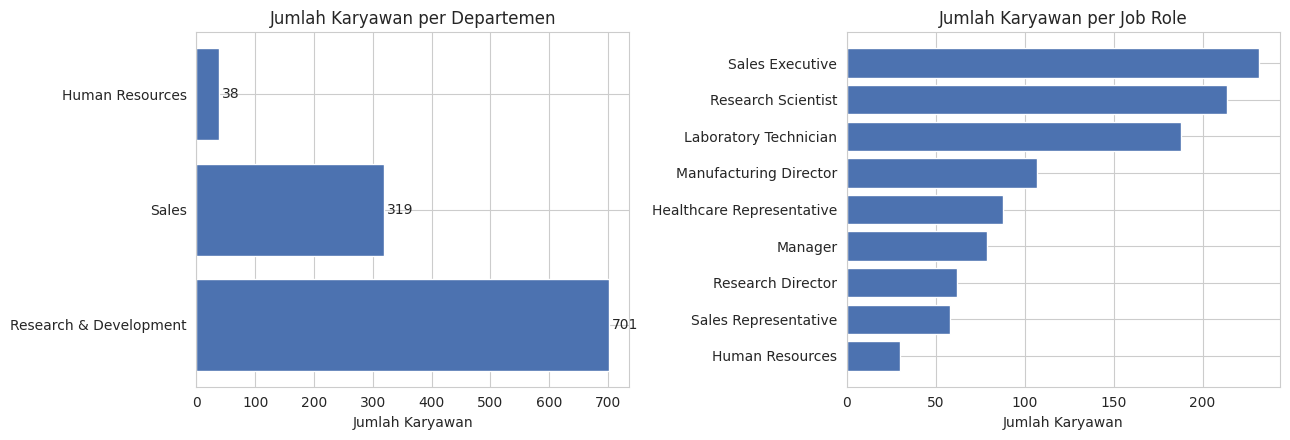

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dept_counts = labeled_fe['Department'].value_counts()
axes[0].barh(dept_counts.index, dept_counts.values, color=COLOR_STAY)
axes[0].set_title('Jumlah Karyawan per Departemen')
axes[0].set_xlabel('Jumlah Karyawan')
for i, v in enumerate(dept_counts.values):
    axes[0].text(v + 5, i, str(v), va='center')

role_counts = labeled_fe['JobRole'].value_counts()
axes[1].barh(role_counts.index[::-1], role_counts.values[::-1], color=COLOR_STAY)
axes[1].set_title('Jumlah Karyawan per Job Role')
axes[1].set_xlabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()


**Apa yang terlihat?**
Mayoritas karyawan (66%) berada di departemen Research & Development, disusul Sales (30%), dan Human Resources paling sedikit (hanya sekitar 4%). Dari sisi job role, Sales Executive, Research Scientist, dan Laboratory Technician adalah tiga role dengan jumlah karyawan terbanyak.

**Artinya apa bagi HR?** Karena R&D dan Sales mendominasi jumlah karyawan, kebijakan HR yang berdampak ke dua departemen ini otomatis akan berdampak besar ke keseluruhan perusahaan. Departemen HR sendiri kecil, jadi perlu perlakuan analisis yang hati-hati (sample size kecil, temuan bisa kurang stabil).

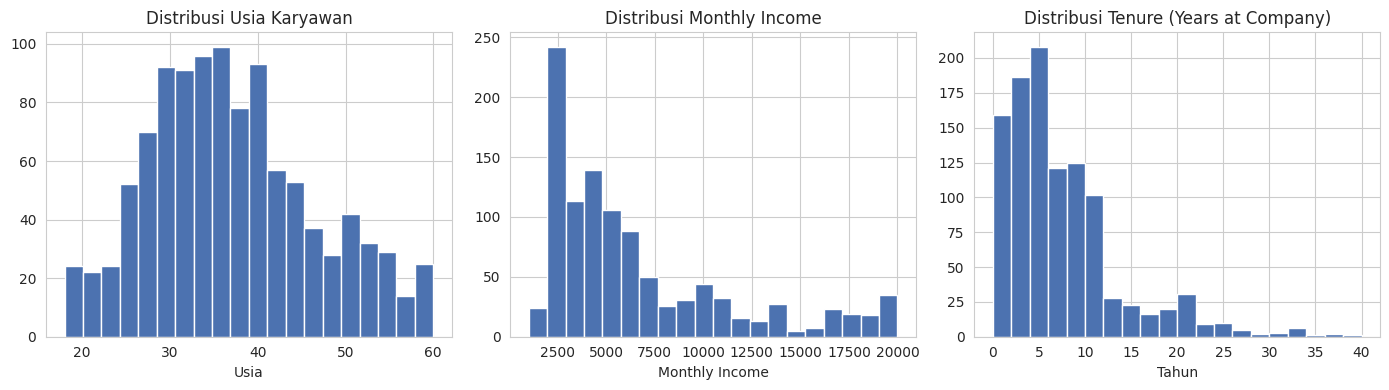

Rata-rata usia          : 37.1 tahun
Rata-rata monthly income: 6,626
Rata-rata tenure        : 7.1 tahun


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(labeled_fe['Age'], bins=20, color=COLOR_STAY, edgecolor='white')
axes[0].set_title('Distribusi Usia Karyawan')
axes[0].set_xlabel('Usia')

axes[1].hist(labeled_fe['MonthlyIncome'], bins=20, color=COLOR_STAY, edgecolor='white')
axes[1].set_title('Distribusi Monthly Income')
axes[1].set_xlabel('Monthly Income')

axes[2].hist(labeled_fe['YearsAtCompany'], bins=20, color=COLOR_STAY, edgecolor='white')
axes[2].set_title('Distribusi Tenure (Years at Company)')
axes[2].set_xlabel('Tahun')

plt.tight_layout()
plt.show()

print(f"Rata-rata usia          : {labeled_fe['Age'].mean():.1f} tahun")
print(f"Rata-rata monthly income: {labeled_fe['MonthlyIncome'].mean():,.0f}")
print(f"Rata-rata tenure        : {labeled_fe['YearsAtCompany'].mean():.1f} tahun")


**Apa yang terlihat?** Usia karyawan terpusat di rentang 28-42 tahun. Distribusi income dan tenure sama-sama miring ke kanan (*right-skewed*) — mayoritas karyawan berpenghasilan menengah ke bawah dan masa kerja masih relatif baru, tapi ada sebagian kecil karyawan senior dengan income tinggi dan tenure panjang.

**Artinya apa bagi HR?** Workforce ini didominasi karyawan usia produktif awal-pertengahan karier. Struktur income yang skewed ini wajar di banyak perusahaan (sedikit posisi senior dengan gaji tinggi), tapi perlu diperhatikan apakah gap ini berkaitan dengan attrition di kelompok income bawah — akan kita cek di bagian berikutnya.

### B. Attrition Analysis

Bagian ini fokus jadi jantung dari EDA: melihat attrition rate secara keseluruhan dan per kelompok karyawan.

Overall Attrition Rate: 16.9%  (179 dari 1058 karyawan)


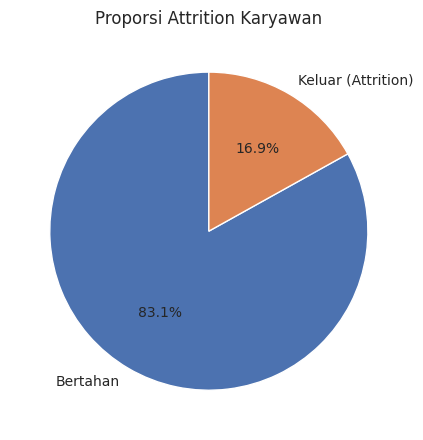

In [ ]:
overall_rate = labeled_fe['Attrition'].mean() * 100
print(f"Overall Attrition Rate: {overall_rate:.1f}%  ({labeled_fe['Attrition'].sum()} dari {len(labeled_fe)} karyawan)")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
counts = labeled_fe['Attrition'].value_counts().sort_index()
ax.pie(counts.values, labels=['Bertahan', 'Keluar (Attrition)'], autopct='%1.1f%%',
       colors=[COLOR_STAY, COLOR_LEAVE], startangle=90)
ax.set_title('Proporsi Attrition Karyawan')
plt.tight_layout()
plt.show()


**Apa yang terlihat?** Dari 1.058 karyawan berlabel, **16.9%** di antaranya sudah keluar dari perusahaan. Ini jadi angka baseline yang akan kita bandingkan dengan attrition rate di tiap kelompok karyawan berikutnya — kalau suatu kelompok attrition rate-nya jauh di atas 16.9%, berarti kelompok itu berisiko lebih tinggi.

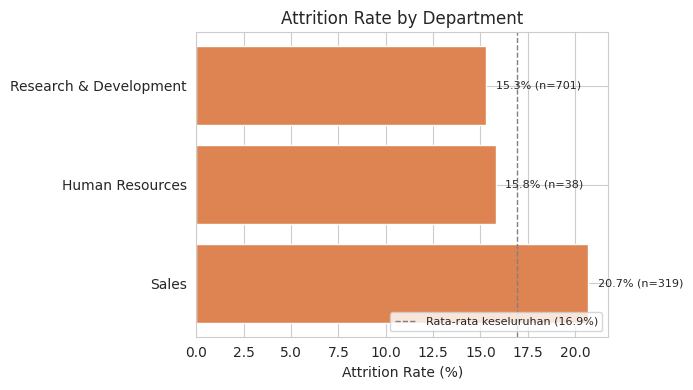

In [ ]:
def attrition_rate_by(col, order=None):
    t = labeled_fe.groupby(col, observed=True)['Attrition'].agg(rate='mean', count='count')
    t['rate'] = (t['rate'] * 100).round(1)
    if order is not None:
        t = t.reindex(order)
    else:
        t = t.sort_values('rate', ascending=False)
    return t

def plot_attrition_rate(col, order=None, title=None, figsize=(7, 4)):
    t = attrition_rate_by(col, order)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(t.index.astype(str), t['rate'], color=COLOR_LEAVE)
    ax.axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Rata-rata keseluruhan ({overall_rate:.1f}%)')
    ax.set_xlabel('Attrition Rate (%)')
    ax.set_title(title or f'Attrition Rate by {col}')
    ax.legend(loc='lower right', fontsize=8)
    for i, (rate, cnt) in enumerate(zip(t['rate'], t['count'])):
        ax.text(rate + 0.5, i, f'{rate}% (n={cnt})', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
    return t

t_dept = plot_attrition_rate('Department', title='Attrition Rate by Department')


**Apa yang terlihat?** Sales punya attrition rate tertinggi (20.7%), disusul Human Resources (15.8%) dan Research & Development (15.3%) yang justru sedikit di bawah rata-rata keseluruhan.

**Artinya apa bagi HR?** Departemen Sales perlu jadi perhatian khusus. Tapi karena Sales juga departemen besar (319 karyawan), gap 20.7% vs 16.9% ini cukup meyakinkan secara jumlah, bukan cuma kebetulan sample kecil.

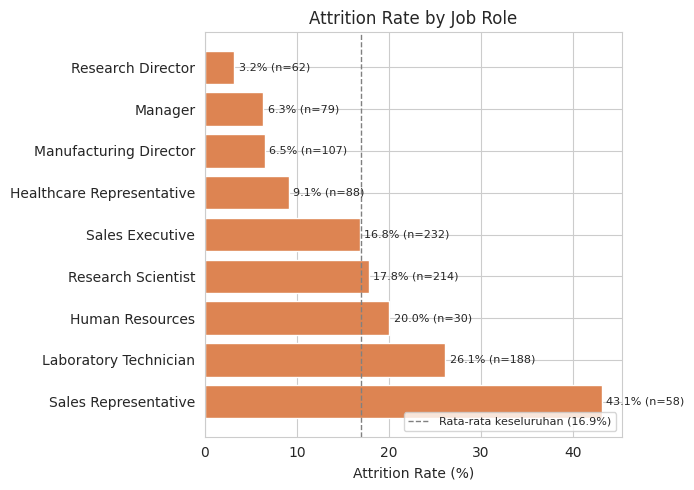

In [ ]:
t_role = plot_attrition_rate('JobRole', title='Attrition Rate by Job Role', figsize=(7, 5))


**Apa yang terlihat?** Ada gap yang cukup lebar antar job role. **Sales Representative** paling tinggi (43.1%), jauh di atas rata-rata. Disusul **Laboratory Technician** (26.1%) dan **Human Resources** (20.0%). Sebaliknya, **Research Director** (3.2%) dan **Manager** (6.3%) punya attrition rate paling rendah.

**Artinya apa bagi HR?** Job role, bukan cuma departemen, ternyata jadi pembeda yang lebih tajam. Sales Representative dengan attrition rate 43% ini sinyal yang sangat kuat — hampir 1 dari 2 karyawan di role ini berisiko keluar. Pola umum yang terlihat: role dengan level lebih junior/operasional (Sales Rep, Lab Technician) cenderung attrition lebih tinggi dibanding role senior/managerial.

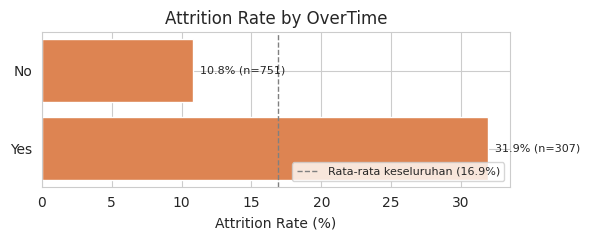

In [ ]:
t_ot = plot_attrition_rate('OverTime', title='Attrition Rate by OverTime', figsize=(6, 2.5))


**Apa yang terlihat?** Karyawan yang sering lembur (`OverTime = Yes`) punya attrition rate **31.9%**, hampir 3 kali lipat dibanding yang tidak lembur (**10.8%**).

**Artinya apa bagi HR?** Ini salah satu sinyal paling kuat di seluruh dataset. Beban kerja berlebih (lembur) tampaknya sangat berkaitan dengan keputusan karyawan untuk keluar. Perlu digarisbawahi: ini korelasi, bukan otomatis penyebab tunggal — bisa jadi lembur berkaitan dengan faktor lain seperti beban kerja tinggi atau kompensasi yang dirasa tidak sepadan.

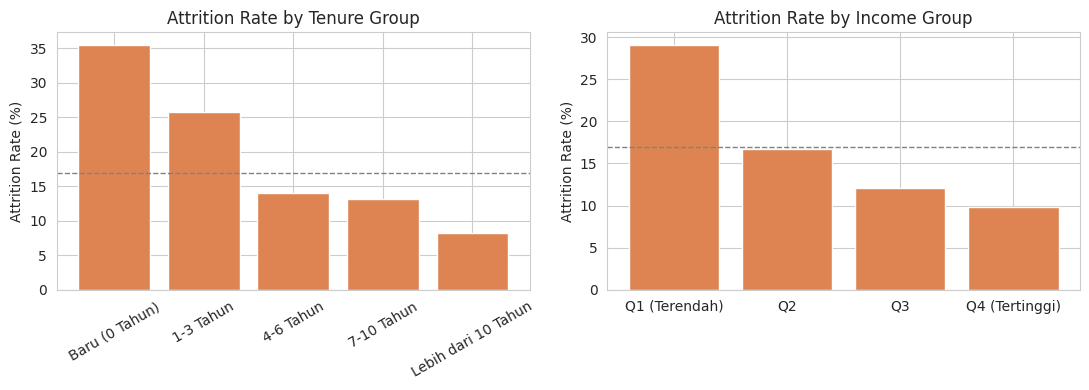

                     rate  count
TenureGroup                     
Baru (0 Tahun)       35.5     31
1-3 Tahun            25.8    314
4-6 Tahun            14.0    265
7-10 Tahun           13.1    268
Lebih dari 10 Tahun   8.3    180

                rate  count
IncomeGroup                
Q1 (Terendah)   29.1    265
Q2              16.7    264
Q3              12.1    264
Q4 (Tertinggi)   9.8    265


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

t_tenure = attrition_rate_by('TenureGroup', order=['Baru (0 Tahun)', '1-3 Tahun', '4-6 Tahun', '7-10 Tahun', 'Lebih dari 10 Tahun'])
axes[0].bar(t_tenure.index.astype(str), t_tenure['rate'], color=COLOR_LEAVE)
axes[0].axhline(overall_rate, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Attrition Rate by Tenure Group')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

t_income = attrition_rate_by('IncomeGroup', order=['Q1 (Terendah)', 'Q2', 'Q3', 'Q4 (Tertinggi)'])
axes[1].bar(t_income.index.astype(str), t_income['rate'], color=COLOR_LEAVE)
axes[1].axhline(overall_rate, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Attrition Rate by Income Group')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

print(t_tenure)
print()
print(t_income)


**Apa yang terlihat?** Attrition rate paling tinggi ada di karyawan dengan tenure baru (0 tahun di perusahaan) dan terus menurun seiring bertambahnya masa kerja. Pola serupa terlihat di income — kelompok income terendah (Q1) attrition rate-nya paling tinggi, dan menurun di kelompok income yang lebih tinggi.

**Artinya apa bagi HR?** Periode awal bekerja adalah masa paling rawan attrition — ini pola umum di banyak perusahaan ("onboarding risk"), tapi tetap penting dikonfirmasi dari data sendiri seperti ini. Income rendah juga jadi faktor risiko, meskipun income dan tenure sendiri kemungkinan saling berkaitan (karyawan baru biasanya juga berada di band income lebih rendah).

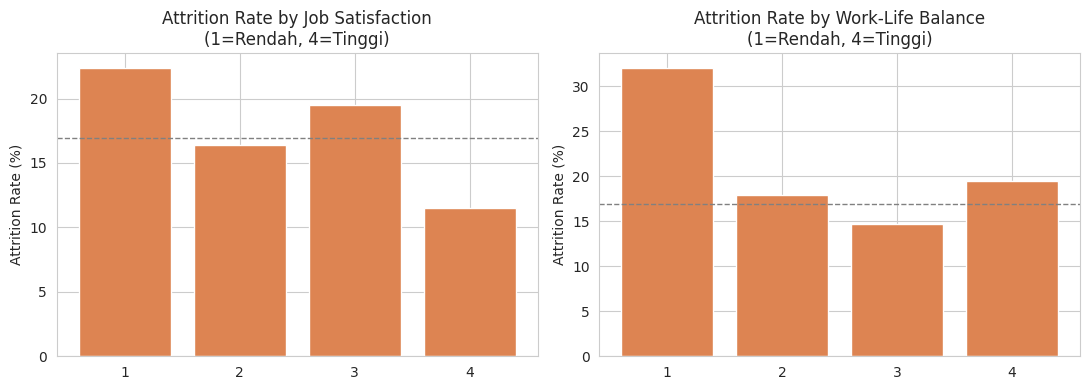

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

t_sat = attrition_rate_by('JobSatisfaction', order=[1, 2, 3, 4])
axes[0].bar(t_sat.index.astype(str), t_sat['rate'], color=COLOR_LEAVE)
axes[0].axhline(overall_rate, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Attrition Rate by Job Satisfaction\n(1=Rendah, 4=Tinggi)')
axes[0].set_ylabel('Attrition Rate (%)')

t_wlb = attrition_rate_by('WorkLifeBalance', order=[1, 2, 3, 4])
axes[1].bar(t_wlb.index.astype(str), t_wlb['rate'], color=COLOR_LEAVE)
axes[1].axhline(overall_rate, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Attrition Rate by Work-Life Balance\n(1=Rendah, 4=Tinggi)')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()


**Apa yang terlihat?** Job satisfaction level 1 (paling rendah) punya attrition rate tertinggi (22.4%) dan menurun di level yang lebih tinggi — meski polanya tidak sepenuhnya linear (level 3 sedikit lebih tinggi dari level 2). Untuk work-life balance, kelompok dengan skor 1 (paling buruk) attrition rate-nya jauh lebih tinggi (32.1%) dibanding kelompok lain.

**Artinya apa bagi HR?** Work-life balance yang buruk tampak sebagai salah satu sinyal terkuat untuk attrition, sejalan dengan temuan soal OverTime sebelumnya. Job satisfaction juga berkaitan, meski tidak se-tajam work-life balance atau overtime.

### C. Relationship Analysis

Melihat hubungan attrition dengan fitur numerik lain secara berdampingan, menggunakan boxplot.

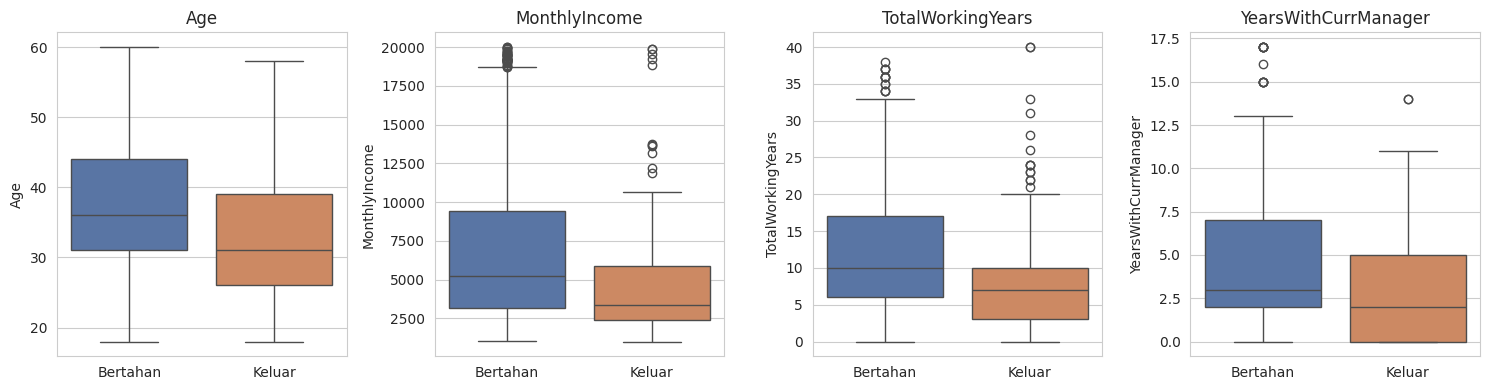

In [ ]:
num_features_to_check = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsWithCurrManager']

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_features_to_check):
    sns.boxplot(data=labeled_fe, x='Attrition', y=col, ax=ax, palette=[COLOR_STAY, COLOR_LEAVE], hue='Attrition', legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Bertahan', 'Keluar'])
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


**Apa yang terlihat?** Karyawan yang keluar cenderung lebih muda (median usia lebih rendah), income lebih kecil, pengalaman kerja total lebih sedikit, dan waktu bekerja dengan manager saat ini lebih singkat, dibanding karyawan yang bertahan.

**Artinya apa bagi HR?** Karyawan yang relatif baru dalam kariernya (baik dari sisi usia, pengalaman, maupun relasi dengan manager saat ini) tampak lebih rentan keluar. Ini memperkuat temuan sebelumnya soal tenure — hubungan kerja yang masih baru (termasuk relasi dengan atasan langsung) adalah periode paling rawan.

### D. Correlation Analysis

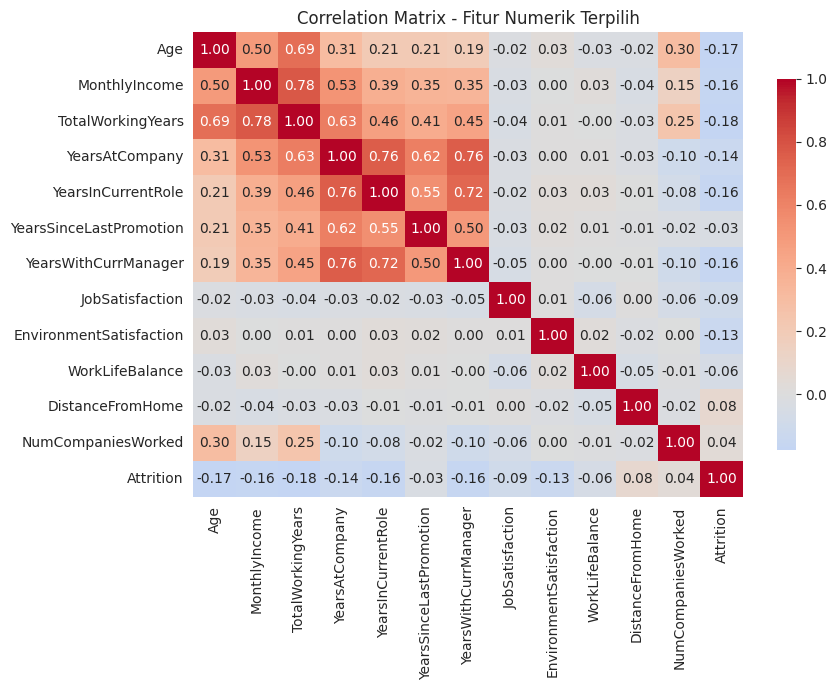

Korelasi tiap fitur dengan Attrition (diurutkan):
TotalWorkingYears         -0.177137
Age                       -0.172067
MonthlyIncome             -0.163600
YearsInCurrentRole        -0.158757
YearsWithCurrManager      -0.155962
YearsAtCompany            -0.135134
EnvironmentSatisfaction   -0.132848
JobSatisfaction           -0.091751
DistanceFromHome           0.078074
WorkLifeBalance           -0.059556
NumCompaniesWorked         0.037429
YearsSinceLastPromotion   -0.031944
Name: Attrition, dtype: float64


In [ ]:
corr_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                  'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
                  'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                  'DistanceFromHome', 'NumCompaniesWorked', 'Attrition']

corr = labeled_fe[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix - Fitur Numerik Terpilih')
plt.tight_layout()
plt.show()

print("Korelasi tiap fitur dengan Attrition (diurutkan):")
print(corr['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False))


**Apa yang terlihat?** Fitur yang paling berkorelasi dengan `Attrition` adalah `TotalWorkingYears`, `YearsWithCurrManager`, `Age`, dan `YearsInCurrentRole` — semuanya berkorelasi negatif, artinya makin besar nilainya makin rendah kemungkinan attrition. Korelasi antar fitur tenure sendiri (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) juga tinggi satu sama lain, yang masuk akal karena ketiganya sama-sama mengukur "berapa lama sudah di sini".

**Artinya apa bagi HR?** Korelasi di sini menunjukkan hubungan, bukan hubungan sebab-akibat — kita tidak bisa bilang "menambah tahun kerja akan mencegah attrition" hanya dari angka ini. Yang bisa disimpulkan adalah bahwa faktor "kematangan" karier (usia, pengalaman, kedekatan dengan manager) punya kaitan konsisten dengan keputusan bertahan/keluar, dan ini konsisten dengan temuan-temuan sebelumnya.

### E. Key EDA Findings

1. **Attrition rate keseluruhan 16.9%** — sekitar 1 dari 6 karyawan di dataset ini sudah keluar dari perusahaan.
2. **OverTime adalah sinyal paling kuat** — karyawan yang sering lembur attrition rate-nya 31.9%, hampir 3x lipat dari yang tidak lembur (10.8%).
3. **Sales Representative adalah role paling berisiko** — attrition rate 43.1%, jauh di atas rata-rata keseluruhan.
4. **Periode awal kerja paling rawan** — attrition rate menurun konsisten seiring bertambahnya tenure, income, dan lama bekerja dengan manager saat ini.
5. **Work-life balance buruk berkaitan kuat dengan attrition** — kelompok dengan skor WLB terendah attrition rate-nya 32.1%, dua kali lipat rata-rata.
6. **Departemen Sales attrition rate tertinggi** (20.7%) dibanding HR (15.8%) dan R&D (15.3%).
7. **Karyawan yang keluar cenderung lebih muda dan kurang berpengalaman** secara keseluruhan (usia, total tahun bekerja, tenure dengan manager saat ini semuanya lebih rendah).

## 6. Predictive Modeling

Setelah memahami pola attrition lewat EDA, sekarang masuk ke sisi Data Scientist: membangun model yang bisa memprediksi kemungkinan seorang karyawan akan attrition.

Target (`Attrition`) berbentuk **binary** (0 = bertahan, 1 = keluar), jadi ini adalah kasus **binary classification**.

Model yang dibandingkan:
1. **Logistic Regression** — dipakai sebagai baseline, karena sederhana dan mudah diinterpretasi
2. **Decision Tree**
3. **Random Forest**
4. **Gradient Boosting**

Karena kelas target imbalanced (83% vs 17%), untuk model yang mendukung parameter `class_weight`, kita set `class_weight='balanced'` supaya model tidak terlalu bias ke kelas mayoritas (karyawan yang bertahan). Semua model memakai `preprocessor` (ColumnTransformer) yang sama lewat `Pipeline`, supaya perbandingan antar model adil.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"{name}: selesai dilatih")


Logistic Regression: selesai dilatih
Decision Tree: selesai dilatih


Random Forest: selesai dilatih


Gradient Boosting: selesai dilatih


> **Catatan soal Gradient Boosting:** `GradientBoostingClassifier` di scikit-learn tidak punya parameter `class_weight`, jadi model ini dilatih tanpa penyeimbangan kelas eksplisit. Ini sengaja dibiarkan apa adanya supaya kita bisa melihat efek nyata dari class imbalance terhadap performanya di tahap evaluasi berikutnya, bukan ditutupi.

## 7. Model Evaluation

Karena kelasnya imbalanced, **accuracy saja bisa menyesatkan** — model yang asal menebak "semua karyawan bertahan" saja sudah bisa dapat accuracy ~83%, padahal gagal total mendeteksi karyawan yang benar-benar attrition. Karena itu kita pakai kombinasi metrik: Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

Untuk kasus HR ini, **Recall** (seberapa banyak karyawan yang benar-benar attrition berhasil terdeteksi model) penting untuk diperhatikan, karena biaya "kelewatan" mendeteksi karyawan berisiko (false negative) lebih mahal buat HR dibanding salah menandai karyawan yang sebenarnya aman (false positive) — HR masih bisa mengecek manual kalau modelnya sedikit terlalu sensitif.

In [ ]:
results = []

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df = results_df.sort_values('F1', ascending=False)
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.731,0.360,0.750,0.486,0.808
Gradient Boosting,0.863,0.733,0.306,0.431,0.803
Decision Tree,0.712,0.264,0.389,0.315,0.584
Random Forest,0.849,0.833,0.139,0.238,0.790


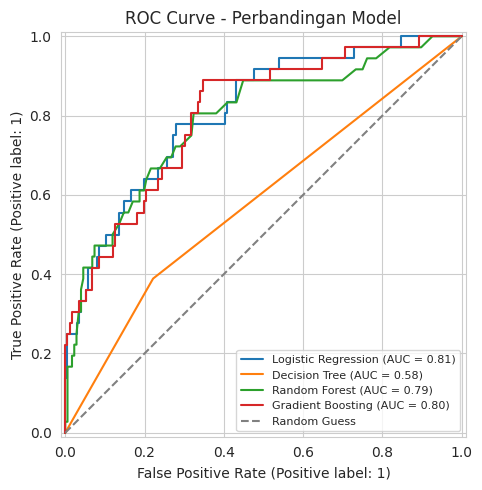

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in trained_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
ax.set_title('ROC Curve - Perbandingan Model')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Membaca hasilnya:**

Random Forest dan Gradient Boosting punya accuracy dan precision tertinggi, tapi recall-nya rendah — artinya kedua model ini "aman main", cenderung memprediksi mayoritas karyawan sebagai "bertahan" dan hanya menangkap sedikit karyawan yang benar-benar attrition. Ini pola klasik ketika model tree-based menghadapi data imbalanced.

**Logistic Regression** punya accuracy paling rendah, tapi **recall dan F1-score paling tinggi**, serta ROC-AUC yang kompetitif dengan model lain. Artinya model ini jauh lebih baik dalam menangkap karyawan yang benar-benar berisiko attrition, meski konsekuensinya sedikit lebih banyak false alarm (precision lebih rendah).

Karena tujuan bisnis project ini adalah membantu HR **mengidentifikasi karyawan berisiko attrition** (bukan sekadar akurat menebak status keseluruhan), model dengan recall dan F1 tinggi lebih relevan dibanding yang cuma unggul di accuracy. Karena itu, **Logistic Regression dipilih sebagai model terbaik** untuk use case ini, meski secara accuracy bukan yang tertinggi.

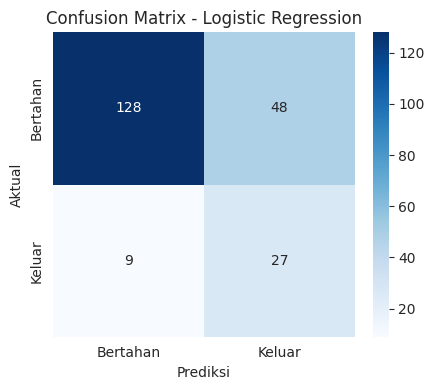

Model terbaik: Logistic Regression
Accuracy     0.731
Precision    0.360
Recall       0.750
F1           0.486
ROC-AUC      0.808
Name: Logistic Regression, dtype: float64


In [ ]:
best_model_name = 'Logistic Regression'
best_pipeline = trained_pipelines[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Bertahan', 'Keluar'], yticklabels=['Bertahan', 'Keluar'])
ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print(f"Model terbaik: {best_model_name}")
print(results_df.loc[best_model_name])


## 8. Model Interpretation

Sekarang kita lihat fitur apa saja yang paling berpengaruh terhadap prediksi model terbaik (Logistic Regression), lewat nilai koefisiennya. Koefisien positif berarti fitur itu berkaitan dengan **meningkatnya** kemungkinan attrition, koefisien negatif berarti **menurunkan** kemungkinan attrition.

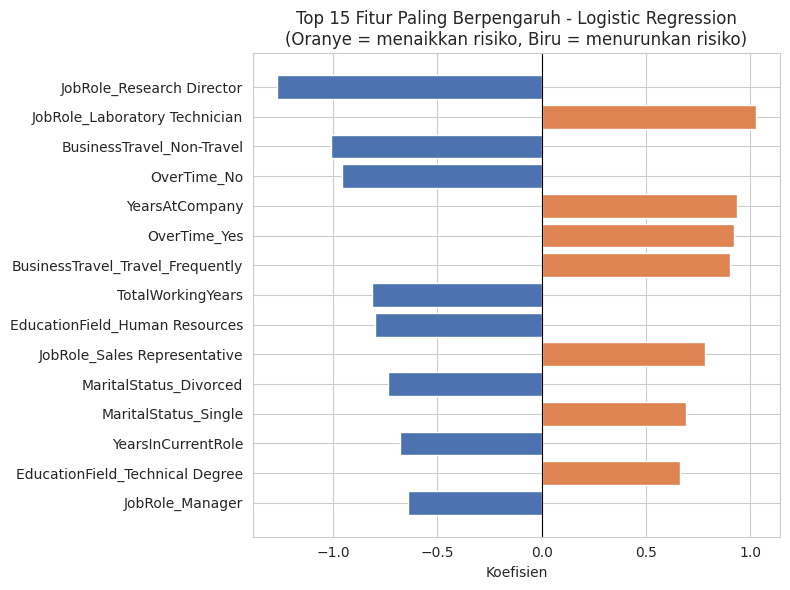

,Feature,Coefficient
42,JobRole_Research Director,-1.268669
39,JobRole_Laboratory Technician,1.027626
23,BusinessTravel_Non-Travel,-1.010879
49,OverTime_No,-0.957272
19,YearsAtCompany,0.938183
50,OverTime_Yes,0.923341
24,BusinessTravel_Travel_Frequently,0.901523
16,TotalWorkingYears,-0.811461
29,EducationField_Human Resources,-0.797418
45,JobRole_Sales Representative,0.781634


In [ ]:
feature_names_num = numerical_features
feature_names_cat = list(
    best_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
all_feature_names = feature_names_num + feature_names_cat

coefs = best_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
top_coef = coef_df.sort_values('AbsCoefficient', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [COLOR_LEAVE if c > 0 else COLOR_STAY for c in top_coef['Coefficient']]
ax.barh(top_coef['Feature'][::-1], top_coef['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Fitur Paling Berpengaruh - Logistic Regression\n(Oranye = menaikkan risiko, Biru = menurunkan risiko)')
ax.set_xlabel('Koefisien')
plt.tight_layout()
plt.show()

top_coef[['Feature', 'Coefficient']]


**Fitur yang menaikkan kemungkinan attrition** (koefisien positif): `OverTime_Yes`, `BusinessTravel_Travel_Frequently`, karyawan dengan job role tertentu seperti Laboratory Technician dan Sales Representative, serta status pernikahan Single.

**Fitur yang menurunkan kemungkinan attrition** (koefisien negatif): job role Research Director, `BusinessTravel_Non-Travel`, `TotalWorkingYears` (makin berpengalaman makin kecil risikonya), dan `YearsInCurrentRole`.

Sebagai pembanding, kita juga cek feature importance dari Gradient Boosting (model dengan pendekatan berbeda — berbasis tree, bukan linear):

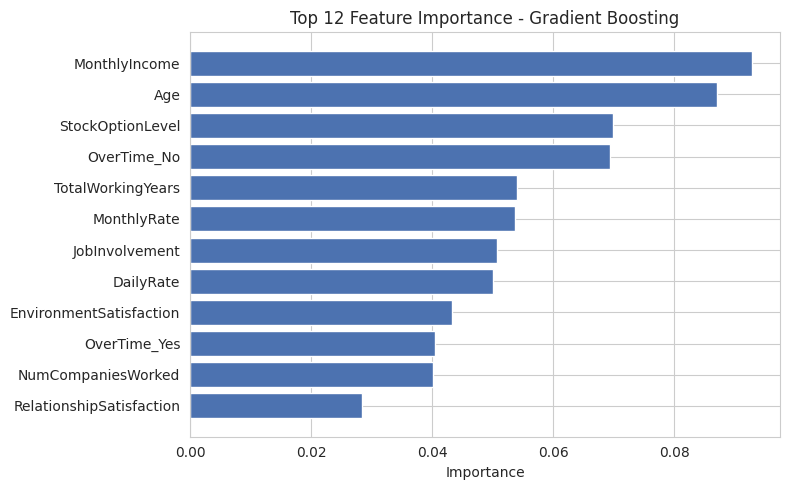

In [ ]:
gb_pipeline = trained_pipelines['Gradient Boosting']
gb_importances = gb_pipeline.named_steps['classifier'].feature_importances_

gb_feature_names_cat = list(
    gb_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
gb_all_feature_names = feature_names_num + gb_feature_names_cat

gb_imp_df = pd.DataFrame({'Feature': gb_all_feature_names, 'Importance': gb_importances})
top_gb_imp = gb_imp_df.sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_gb_imp['Feature'][::-1], top_gb_imp['Importance'][::-1], color=COLOR_STAY)
ax.set_title('Top 12 Feature Importance - Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


**Perbandingan kedua model:** meski pendekatannya beda (linear vs tree-based), ada tema yang konsisten muncul di keduanya: **OverTime**, **tenure/pengalaman kerja** (`TotalWorkingYears`), dan **income/stock option** sama-sama muncul sebagai faktor penting. Ini memperkuat keyakinan bahwa faktor-faktor ini memang benar-benar berkaitan dengan attrition, bukan cuma kebetulan dari satu model tertentu.

Penting digarisbawahi: hasil ini menunjukkan **fitur mana yang berkontribusi besar terhadap prediksi model**, bukan bukti bahwa fitur tersebut *menyebabkan* attrition. Misalnya, "OverTime memiliki kontribusi besar terhadap prediksi attrition" — bukan "OverTime menyebabkan karyawan resign". Bisa saja OverTime berkaitan dengan faktor lain yang tidak tercatat di data (misalnya budaya kerja tim tertentu) yang menjadi penyebab sebenarnya.

## 9. Employee Risk Profile

Menggabungkan temuan EDA dan model, berikut profil karyawan yang secara data punya karakteristik risiko attrition lebih tinggi:

| Karakteristik | Detail |
|---|---|
| **OverTime** | Sering lembur (`OverTime = Yes`) — attrition rate 31.9% vs 10.8% |
| **Job Role** | Sales Representative (43.1%) atau Laboratory Technician (26.1%) |
| **Tenure** | Karyawan baru, terutama di tahun pertama bekerja |
| **Work-Life Balance** | Skor rendah (1 dari skala 1-4) — attrition rate 32.1% |
| **Business Travel** | Sering melakukan perjalanan dinas (`Travel_Frequently`) — 24.9% |
| **Status Pernikahan** | Single — attrition rate 26.7% vs Married 13.4% |
| **Income** | Berada di kuartil income terendah |

Semua karakteristik di atas didukung langsung oleh angka attrition rate dari data (bagian EDA) dan/atau muncul sebagai fitur penting di model (bagian Model Interpretation) — bukan asumsi di luar data.

### Simulasi Penerapan Model: Skor Risiko untuk Karyawan yang Belum Berlabel

Ingat di awal ada 412 karyawan yang status attrition-nya belum diketahui (`unlabeled`). Di sinilah model machine learning benar-benar berguna secara praktis: kita bisa pakai model terbaik untuk memberi **skor probabilitas risiko attrition** ke tiap karyawan tersebut, supaya HR bisa memprioritaskan mana yang perlu diperhatikan lebih dulu.

In [ ]:
unlabeled_features = unlabeled[feature_cols]

risk_scores = best_pipeline.predict_proba(unlabeled_features)[:, 1]

risk_df = unlabeled[['EmployeeId', 'Department', 'JobRole', 'OverTime', 'YearsAtCompany']].copy()
risk_df['AttritionRiskScore'] = (risk_scores * 100).round(1)
risk_df = risk_df.sort_values('AttritionRiskScore', ascending=False)

print(f"Total karyawan yang diberi skor risiko: {len(risk_df)}")
print()
print("10 karyawan dengan risiko attrition tertinggi:")
risk_df.head(10)


Total karyawan yang diberi skor risiko: 412

10 karyawan dengan risiko attrition tertinggi:


,EmployeeId,Department,JobRole,OverTime,YearsAtCompany,AttritionRiskScore
948,949,Research & Development,Laboratory Technician,Yes,0,99.3
741,742,Sales,Sales Executive,No,23,98.3
1273,1274,Research & Development,Research Director,Yes,32,98.0
1363,1364,Sales,Sales Executive,Yes,2,97.7
1443,1444,Research & Development,Research Scientist,Yes,6,97.3
1249,1250,Research & Development,Research Scientist,Yes,1,97.0
615,616,Research & Development,Laboratory Technician,No,0,96.8
697,698,Sales,Sales Representative,Yes,0,96.2
1138,1139,Research & Development,Laboratory Technician,Yes,4,95.7
97,98,Sales,Sales Executive,Yes,2,95.3


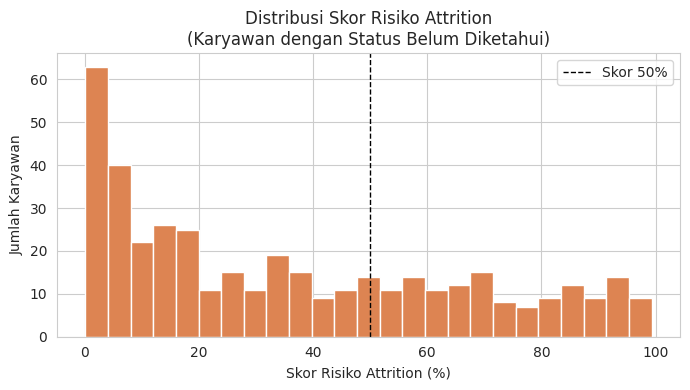

Karyawan dengan skor risiko >= 50%: 140 dari 412 (34.0%)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(risk_df['AttritionRiskScore'], bins=25, color=COLOR_LEAVE, edgecolor='white')
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='Skor 50%')
ax.set_title('Distribusi Skor Risiko Attrition\n(Karyawan dengan Status Belum Diketahui)')
ax.set_xlabel('Skor Risiko Attrition (%)')
ax.set_ylabel('Jumlah Karyawan')
ax.legend()
plt.tight_layout()
plt.show()

high_risk_count = (risk_df['AttritionRiskScore'] >= 50).sum()
print(f"Karyawan dengan skor risiko >= 50%: {high_risk_count} dari {len(risk_df)} ({high_risk_count/len(risk_df)*100:.1f}%)")


Dengan pendekatan ini, HR tidak perlu menunggu karyawan benar-benar resign untuk bertindak — cukup fokus ke daftar karyawan dengan skor risiko tertinggi untuk intervensi lebih dulu (misalnya 1-on-1 check-in, review beban kerja, atau diskusi jenjang karier).

## 10. Key Business Insights

### Insight 1 — Lembur adalah red flag terbesar

**Temuan:** Karyawan yang sering lembur (`OverTime = Yes`) punya attrition rate 31.9%, dibanding hanya 10.8% pada karyawan yang tidak lembur. `OverTime` juga konsisten muncul sebagai salah satu fitur terpenting baik di Logistic Regression maupun Gradient Boosting.

**Makna bisnis:** Beban kerja berlebih tampak sebagai salah satu pemicu attrition paling kuat di seluruh dataset. Ini sinyal yang paling actionable karena HR/manajer bisa langsung memantau dan mengatur ulang beban kerja tim.

### Insight 2 — Sales Representative adalah role dengan risiko tertinggi

**Temuan:** Attrition rate Sales Representative mencapai 43.1% — jauh di atas rata-rata perusahaan (16.9%) dan di atas job role lain manapun.

**Makna bisnis:** Ada sesuatu yang spesifik pada role ini (bisa jadi tekanan target, kompensasi, atau jenjang karier yang kurang jelas) yang membuat retensinya jauh lebih sulit dibanding role lain. Role ini perlu jadi prioritas investigasi lebih lanjut.

### Insight 3 — Tahun pertama bekerja adalah periode paling rawan

**Temuan:** Attrition rate menurun konsisten seiring bertambahnya tenure — dari kelompok karyawan baru sampai yang sudah lebih dari 10 tahun bekerja. Pola serupa terlihat pada `YearsInCurrentRole` dan `YearsWithCurrManager`.

**Makna bisnis:** Proses onboarding dan pendampingan di tahun-tahun pertama tampaknya krusial. Karyawan yang berhasil melewati fase awal cenderung jauh lebih stabil.

### Insight 4 — Work-life balance yang buruk berkaitan kuat dengan attrition

**Temuan:** Karyawan dengan skor Work-Life Balance terendah (1 dari skala 1-4) punya attrition rate 32.1%, dua kali lipat rata-rata keseluruhan.

**Makna bisnis:** Ini melengkapi temuan soal OverTime — dua-duanya mengarah ke tema yang sama: beban dan keseimbangan kerja adalah area yang paling berkaitan dengan keputusan karyawan untuk bertahan atau keluar.

### Insight 5 — Karyawan Single lebih rentan dibanding yang sudah menikah

**Temuan:** Attrition rate karyawan berstatus Single adalah 26.7%, hampir dua kali lipat dibanding yang Married (13.4%) dan jauh di atas yang Divorced (9.5%).

**Makna bisnis:** Faktor personal/life-stage karyawan juga berkaitan dengan attrition, meski ini faktor yang jelas tidak bisa "diintervensi" HR — lebih berguna sebagai konteks tambahan dibanding dasar aksi langsung.

### Insight 6 — Model machine learning bisa mendeteksi mayoritas karyawan berisiko, meski accuracy-nya bukan yang tertinggi

**Temuan:** Logistic Regression sebagai model terbaik berhasil mendapatkan recall tertinggi di antara semua model yang dicoba — jauh lebih baik dalam menangkap karyawan yang benar-benar berisiko attrition dibanding model dengan accuracy lebih tinggi seperti Random Forest atau Gradient Boosting.

**Makna bisnis:** Untuk use case HR seperti ini, memilih model bukan cuma soal angka accuracy tertinggi, tapi model mana yang paling sesuai dengan konsekuensi bisnisnya — lebih baik menandai lebih banyak karyawan berisiko (meski sebagian ternyata false alarm) daripada kelewatan mendeteksi karyawan yang benar-benar akan keluar.

### Insight 7 — Faktor income dan job level ikut berperan, tapi levelnya lebih halus dibanding overtime dan tenure

**Temuan:** Attrition rate menurun dari kelompok income terendah (Q1) ke tertinggi (Q4), dan pola serupa terlihat di `JobLevel` — level 1 (paling junior) attrition rate 27.4%, terus menurun sampai level 4 (5.0%).

**Makna bisnis:** Kompensasi dan jenjang karier berperan, tapi berdasarkan urutan kekuatan sinyal di EDA maupun model, faktor ini levelnya lebih halus dibanding OverTime, job role, dan tenure — kemungkinan karena income dan job level sendiri berkorelasi kuat dengan tenure.

## 11. Business Recommendations

### Recommendation 1 — Audit dan batasi jam lembur, terutama di tim dengan beban kerja tinggi

**Masalah:** Attrition rate karyawan yang sering lembur (31.9%) hampir 3x lipat dari yang tidak (10.8%).

**Temuan:** `OverTime` konsisten jadi fitur terpenting di dua model berbeda (Logistic Regression dan Gradient Boosting).

**Tindakan:** Lakukan audit distribusi jam lembur per tim/departemen, identifikasi tim dengan lembur berlebihan secara konsisten, dan evaluasi apakah perlu penambahan headcount atau redistribusi beban kerja.

**Target:** Tim/departemen dengan proporsi karyawan `OverTime = Yes` di atas rata-rata perusahaan, terutama di Sales dan R&D yang jumlah karyawannya besar.

**Expected impact:** Mengurangi salah satu pemicu attrition terkuat yang teridentifikasi di data, berpotensi menurunkan attrition rate signifikan di kelompok yang saat ini paling terdampak.

### Recommendation 2 — Rancang program retensi khusus untuk role Sales Representative

**Masalah:** Attrition rate Sales Representative (43.1%) jauh di atas rata-rata perusahaan (16.9%).

**Temuan:** Ini adalah gap attrition rate terbesar antar job role di seluruh dataset.

**Tindakan:** Lakukan exit interview terfokus dan survei kepuasan khusus untuk role ini, review struktur kompensasi/insentif (base salary vs komisi), dan evaluasi jenjang karier yang tersedia untuk role ini.

**Target:** Seluruh karyawan dengan `JobRole = Sales Representative` (58 karyawan di data berlabel, kemungkinan proporsi serupa di 412 karyawan lain).

**Expected impact:** Menurunkan attrition rate role dengan risiko tertinggi ini akan memberi dampak besar terhadap penurunan attrition rate departemen Sales secara keseluruhan.

### Recommendation 3 — Perkuat program onboarding dan mentoring di tahun pertama

**Masalah:** Attrition rate tertinggi ada pada karyawan dengan tenure paling baru, dan menurun konsisten seiring bertambahnya masa kerja.

**Temuan:** Pola serupa berlaku juga untuk `YearsInCurrentRole` dan `YearsWithCurrManager` — semakin baru relasinya, semakin tinggi risikonya.

**Tindakan:** Perkuat program onboarding terstruktur (check-in rutin di bulan 1, 3, 6), sediakan program mentoring/buddy system khusus untuk karyawan baru, dan pastikan manager baru dilatih untuk membangun relasi kerja yang solid sejak awal.

**Target:** Seluruh karyawan baru dengan tenure kurang dari 1 tahun.

**Expected impact:** Mengurangi attrition di fase paling rawan (tahun pertama), yang berdasarkan data adalah periode dengan risiko tertinggi di seluruh siklus kerja karyawan.

### Recommendation 4 — Evaluasi kebijakan work-life balance dan business travel

**Masalah:** Karyawan dengan skor work-life balance terendah punya attrition rate 32.1% (dua kali lipat rata-rata), dan karyawan yang sering melakukan perjalanan dinas juga attrition rate-nya lebih tinggi (24.9%).

**Temuan:** Kedua faktor ini konsisten menunjukkan pola yang sama dengan temuan soal OverTime — sama-sama mengarah ke tema beban dan keseimbangan kerja.

**Tindakan:** Tinjau ulang kebijakan frekuensi perjalanan dinas (apakah semuanya benar-benar perlu tatap muka), dan pertimbangkan kebijakan fleksibilitas kerja (remote/hybrid) untuk role yang memungkinkan.

**Target:** Karyawan dengan `BusinessTravel = Travel_Frequently` dan/atau skor Work-Life Balance rendah (1-2).

**Expected impact:** Memperbaiki persepsi keseimbangan kerja-hidup, yang berdasarkan data berkaitan erat dengan keputusan bertahan/keluar.

### Recommendation 5 — Gunakan model prediksi sebagai early warning system, bukan alat justifikasi keputusan sepihak

**Masalah:** HR sering baru menyadari masalah attrition setelah karyawan resign, sehingga sulit melakukan intervensi tepat waktu.

**Temuan:** Model Logistic Regression bisa memberi skor risiko attrition untuk karyawan aktif, termasuk 412 karyawan yang status attrition-nya belum diketahui di dataset ini.

**Tindakan:** Integrasikan skor risiko attrition ke dashboard HR bulanan, gunakan sebagai bahan diskusi 1-on-1 (bukan alasan tunggal untuk keputusan personel), dan lakukan validasi berkala dengan membandingkan prediksi vs kejadian aktual.

**Target:** Karyawan dengan skor risiko attrition di atas 50%, terutama yang juga masuk kategori job role/departemen berisiko tinggi.

**Expected impact:** HR bisa lebih proaktif dan terarah dalam alokasi effort retensi, alih-alih bereaksi setelah karyawan sudah resign.

## 12. Limitations

- **Data historis, bukan real-time.** Dataset ini adalah snapshot kondisi karyawan pada satu titik waktu, sehingga tidak menangkap perubahan situasi karyawan setelah data diambil.
- **Korelasi bukan sebab-akibat.** Semua hubungan yang ditemukan (misalnya OverTime dengan attrition) adalah korelasi/asosiasi dari data historis, bukan bukti hubungan kausal yang sudah diuji secara eksperimen.
- **Class imbalance.** Attrition rate 16.9% membuat model relatif sulit mendeteksi kelas minoritas dengan sempurna — trade-off antara precision dan recall tetap ada meski sudah ditangani dengan `class_weight`.
- **Model belum divalidasi di data benar-benar baru.** Skor risiko yang diberikan ke 412 karyawan belum berlabel adalah simulasi — validasi sesungguhnya baru bisa dilakukan setelah status attrition mereka benar-benar diketahui di masa depan.
- **Belum mempertimbangkan biaya bisnis secara eksplisit.** Model dipilih berdasarkan recall dan F1, tapi belum memasukkan estimasi biaya nyata dari false positive (effort HR yang terbuang) vs false negative (kehilangan karyawan tanpa peringatan).
- **Kemungkinan perubahan pola dari waktu ke waktu.** Pola attrition bisa berubah seiring waktu (misalnya karena perubahan kebijakan perusahaan, kondisi ekonomi, atau tren pasar kerja), sehingga model ini perlu dievaluasi dan dilatih ulang secara berkala.

## 13. Conclusion

Dataset ini berisi data 1.470 karyawan, dengan 1.058 di antaranya punya label attrition yang jelas — attrition rate keseluruhan berada di angka **16.9%**.

Dari sisi **Data Analyst**, EDA menunjukkan bahwa attrition paling terkait dengan **beban kerja** (OverTime, work-life balance, business travel), **job role** (khususnya Sales Representative dengan attrition rate 43.1%), dan **tahap awal hubungan kerja** (tenure baru, relasi manager baru).

Dari sisi **Data Scientist**, empat model klasifikasi dibandingkan (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting). **Logistic Regression** dipilih sebagai model terbaik karena recall dan F1-score paling tinggi di antara semua model, meski accuracy-nya bukan yang tertinggi — pilihan ini didasarkan pada kebutuhan bisnis untuk mendeteksi sebanyak mungkin karyawan berisiko, bukan cuma akurat secara agregat. Fitur yang paling berpengaruh terhadap prediksi model konsisten dengan temuan EDA: OverTime, business travel, job role, dan tenure/pengalaman kerja.

Berdasarkan temuan ini, lima rekomendasi bisnis dirumuskan — mulai dari audit jam lembur, program retensi khusus Sales Representative, penguatan onboarding, evaluasi kebijakan work-life balance, sampai penerapan model sebagai early warning system.

**Langkah selanjutnya** yang bisa dilakukan: mengumpulkan data tambahan (misalnya hasil survei kepuasan yang lebih detail atau data exit interview), memvalidasi skor risiko model terhadap kejadian attrition aktual di masa depan, dan melakukan re-training model secara berkala seiring bertambahnya data baru.

## 14. Dashboard Recommendation (Power BI)

Sebagai pelengkap notebook ini, berikut rancangan dashboard Power BI yang bisa dipakai tim HR untuk memonitor kondisi workforce dan attrition secara berkelanjutan, berdasarkan variabel-variabel yang tersedia di dataset ini.

### Page 1 — Workforce Overview
- **KPI Cards:** Total Employees, Overall Attrition Rate, Average Tenure, Average Monthly Income
- **Bar Chart:** Jumlah karyawan per Department dan per Job Role
- **Histogram:** Distribusi usia dan tenure karyawan

### Page 2 — Attrition Analysis
- **Bar Chart:** Attrition Rate by Department, by Job Role
- **Bar Chart:** Attrition Rate by Tenure Group, by OverTime
- **Bar Chart:** Attrition Rate by Job Satisfaction & Work-Life Balance
- **Trend perbandingan** tiap kategori terhadap rata-rata attrition rate perusahaan (garis referensi)

### Page 3 — Employee Profile
- **Filter interaktif:** Department, Job Role, Gender, Marital Status
- **Scatter/Table:** Income vs Tenure vs Attrition Risk Score
- **Breakdown demografis:** usia, gender, education field

### Page 4 — HR Action
- **Tabel:** Daftar karyawan dengan Attrition Risk Score tertinggi (hasil model), lengkap dengan Department, Job Role, dan OverTime status
- **Summary Key Insights:** ringkasan 7 insight utama dari notebook ini
- **High-Risk Groups:** kartu ringkasan kelompok berisiko tinggi (Sales Representative, OverTime=Yes, tenure baru, WLB rendah)
- **Recommended Actions:** daftar 5 rekomendasi dari notebook ini sebagai referensi cepat tim HR

Dashboard ini idealnya di-refresh berkala (misalnya bulanan) seiring data HR diperbarui, supaya attrition rate dan skor risiko yang ditampilkan selalu mencerminkan kondisi terkini.